In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("../data/data.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df = df.drop(columns = ['id','Unnamed: 32'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [6]:
print(df['diagnosis'].unique())
print(df['diagnosis'].head())

['M' 'B']
0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object


In [100]:

df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})



In [101]:
b =( (df['diagnosis'].value_counts().iloc[0]) / len(df)) *100
print("Benign casses : ",b)
m = (df['diagnosis'].value_counts()[1] / len(df)) * 100
print("Malignt cases :",m)


IndexError: single positional indexer is out-of-bounds

In [102]:
df.isnull().sum()

diagnosis                  569
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
dtype: int64

In [87]:

df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.065138,0.834164,0.867619,0.994404,1.096268,0.084098,0.079503,0.059374,0.034161,0.142511,...,0.847906,0.894674,1.003554,1.107108,0.110280,0.173223,0.174915,0.094276,0.201901,0.048584
std,0.084603,0.025269,0.021845,0.016199,0.020914,0.010467,0.029993,0.039816,0.020759,0.016261,...,0.028180,0.022153,0.018155,0.022751,0.015626,0.073022,0.099104,0.047293,0.026781,0.005317
min,0.000000,0.768054,0.807998,0.951014,1.040201,0.054749,0.018487,0.000000,0.000000,0.098797,...,0.771199,0.831975,0.954485,1.043793,0.068406,0.026221,0.000000,0.000000,0.132103,0.037587
25%,0.000000,0.817389,0.852838,0.983541,1.082511,0.076580,0.055932,0.026800,0.018110,0.130863,...,0.829390,0.879497,0.991214,1.092106,0.099501,0.121047,0.097964,0.059221,0.183725,0.044612
50%,0.000000,0.832417,0.868450,0.992894,1.095191,0.083971,0.075406,0.050716,0.027917,0.142003,...,0.844693,0.897104,1.001102,1.105026,0.110047,0.161941,0.170520,0.087076,0.200493,0.047828
75%,0.174828,0.850279,0.882731,1.005226,1.110718,0.091135,0.098786,0.090173,0.051406,0.152240,...,0.868185,0.911178,1.016909,1.124315,0.120231,0.228083,0.247481,0.130534,0.218140,0.051907
max,0.174828,0.883169,0.912714,1.026705,1.132377,0.111731,0.147024,0.144282,0.080879,0.181541,...,0.904150,0.941487,1.040522,1.146832,0.148807,0.334015,0.376540,0.204953,0.262478,0.060561


IndexError: index 15 is out of bounds for axis 0 with size 15

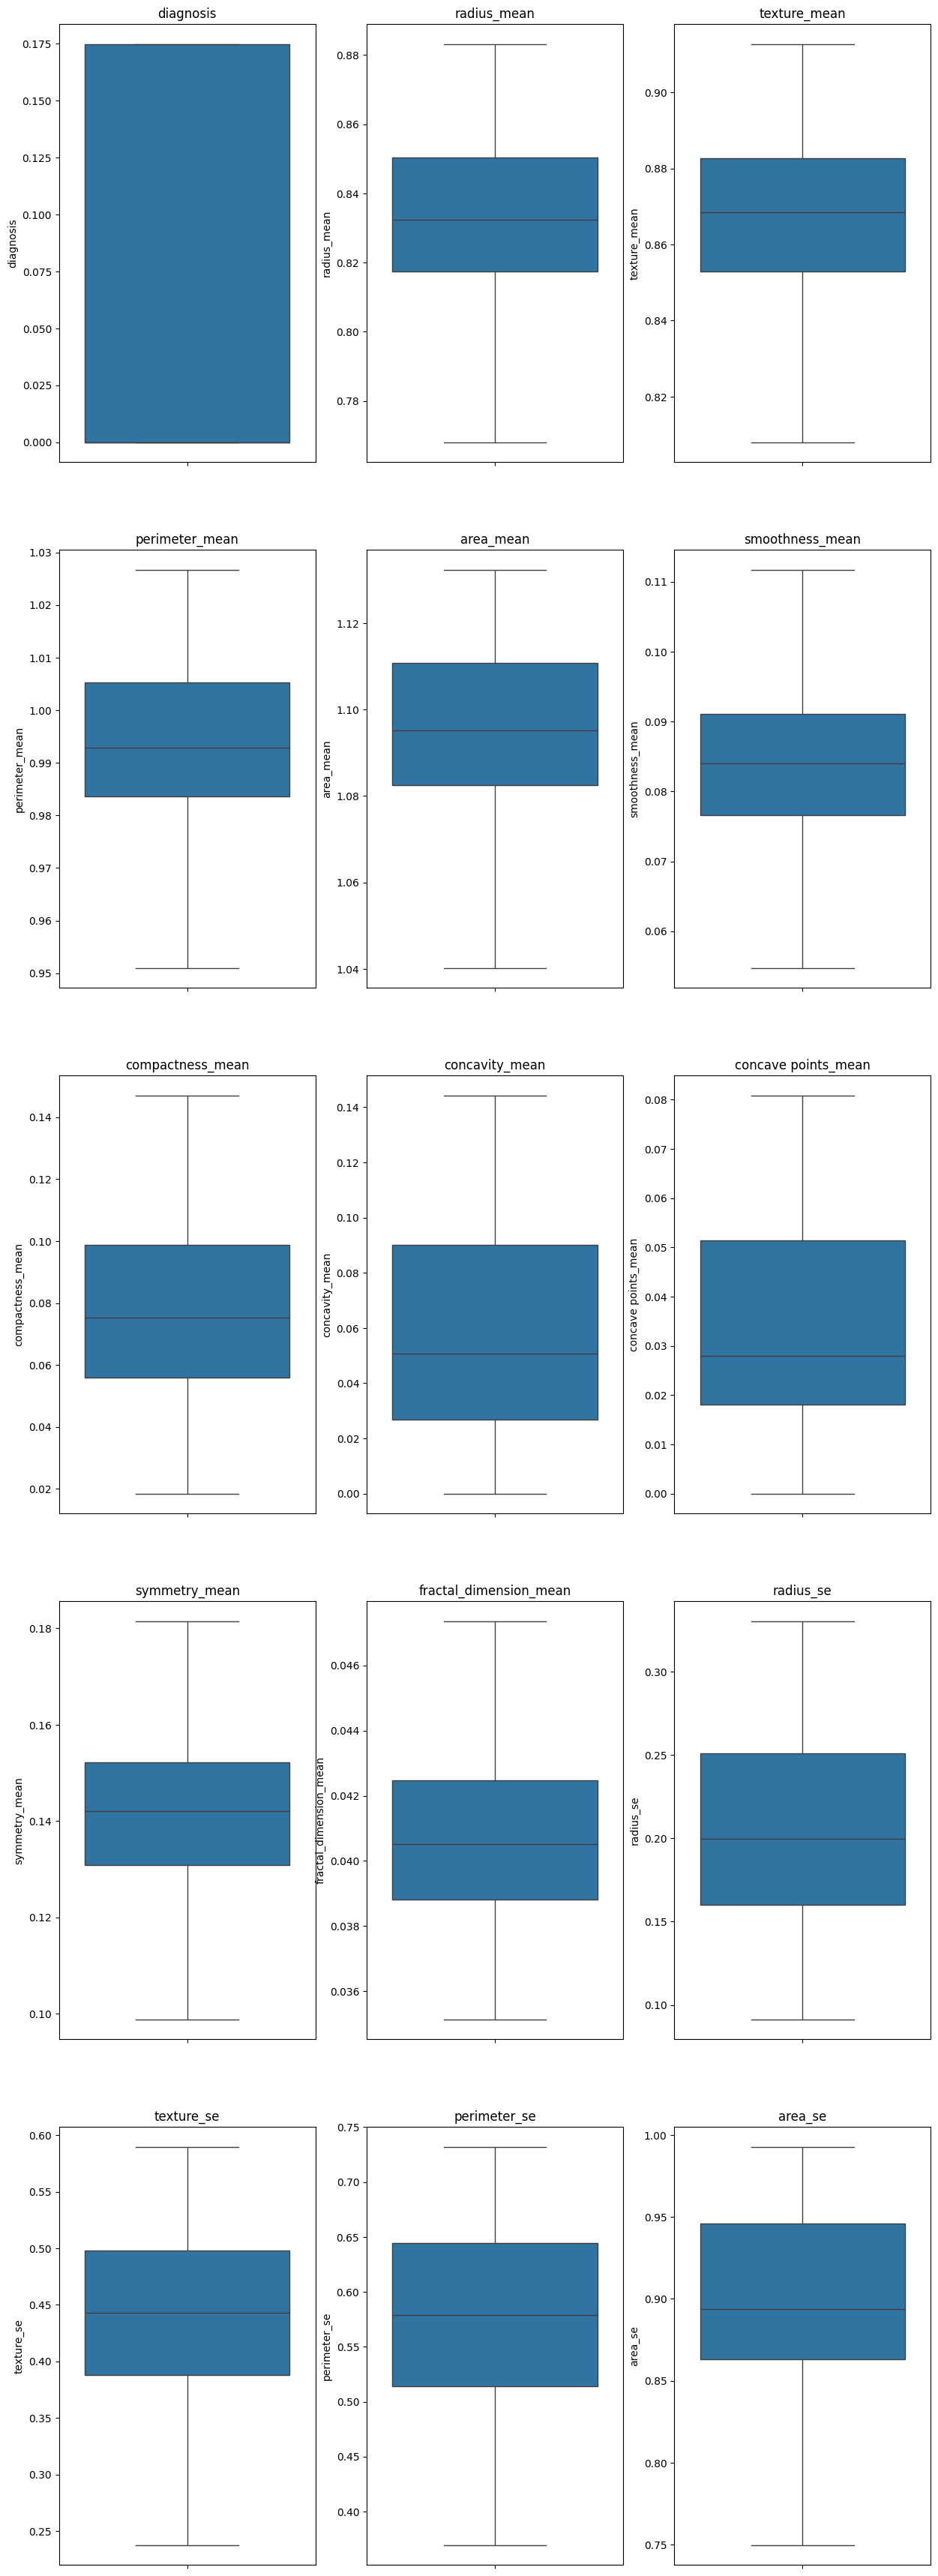

In [88]:
import math
cols = df.columns
n = len(cols)
rows = math.ceil(n/3)
fig ,axes = plt.subplots(nrows = 5 , ncols =3 , figsize = (15,rows*4))

axes = axes.flatten()
for i , col in enumerate(cols):
    sns.boxplot(df[col],ax =axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()
    

removing outliers

In [89]:
for col in df.columns:
    if col == 'diagnosis':
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    df[col] = df[col].clip(lower,upper)

checking for skewness 

IndexError: index 15 is out of bounds for axis 0 with size 15

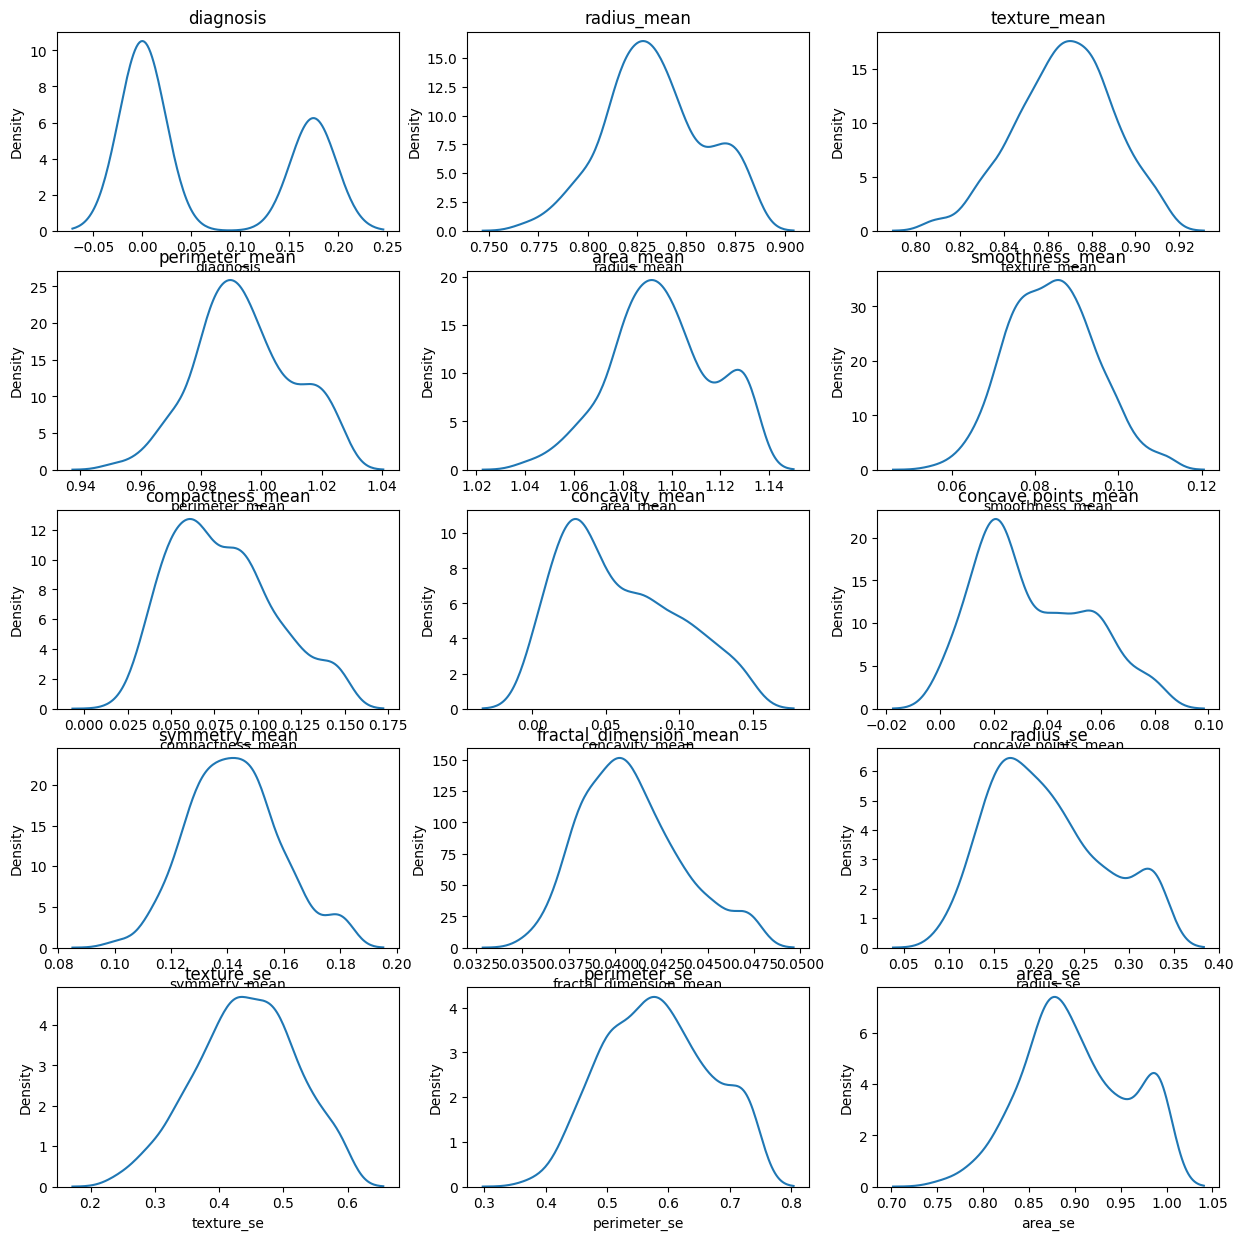

In [90]:

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fixing skewness of the data


In [91]:
skew = df.skew()

high_skew = skew[abs(skew)>0.5]
print(high_skew)



diagnosis                  0.528461
fractal_dimension_mean     0.522166
smoothness_se              0.701128
compactness_se             0.637465
symmetry_se                0.688244
fractal_dimension_se       0.922762
fractal_dimension_worst    0.508715
dtype: float64


In [92]:
cols_1= skew[abs(skew)>0.5].index
cols_1 = [c for c in cols_1 if c != 'diagnosis']
for col in cols_1:
    df[col] = np.log1p(df[col])

## Training and Testing 

In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , cross_val_score  , RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier


In [94]:
X = df.drop(columns='diagnosis')
y = df['diagnosis'].copy()
print('diagnosis dtype:', y.dtype)
print('diagnosis unique sample:', pd.unique(y)[:20])
print('value counts before mapping:')
print(y.value_counts(dropna=False).head(10))
if y.dtype == object or y.dtype.name == 'string':
    y = y.str.strip()
    y = y.map({'M': 1, 'B': 0})
else:
    uniques = pd.unique(y.dropna())
    uniques_sorted = sorted(uniques)
    if len(uniques_sorted) == 2:
        mapping = {uniques_sorted[0]: 0, uniques_sorted[1]: 1}
        print('Mapping numeric codes to 0/1:', mapping)
        y = y.replace(mapping)
    else:
        if 0.17482829 in uniques_sorted:
            y = y.replace({0.17482829: 1})
        print('Post-fallback unique values:', pd.unique(y))
mask = y.isin([0, 1])
dropped = (~mask).sum()
if dropped>0:
    print(f'Dropping {dropped} rows where diagnosis could not be mapped to 0/1. Sample values:', pd.unique(y[~mask])[:10])
X = X[mask].reset_index(drop=True)
y = y[mask].astype(int).reset_index(drop=True)
print('Final y.unique():', y.unique())
print('Final y counts:')
print(y.value_counts())

diagnosis dtype: float64
diagnosis unique sample: [0.17482829 0.        ]
value counts before mapping:
diagnosis
0.000000    357
0.174828    212
Name: count, dtype: int64
Mapping numeric codes to 0/1: {np.float64(0.0): 0, np.float64(0.17482829370651073): 1}
Final y.unique(): [1 0]
Final y counts:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [95]:
y.unique()

array([1, 0])

In [96]:
X_train , X_test, y_train ,y_test = train_test_split(X,y, test_size=0.2,random_state=11 ,stratify=y)

In [97]:
lr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',LogisticRegression(max_iter= 10000))
])
lr_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [99]:
from sklearn.metrics import accuracy_score,confusion_matrix
y_pred_lr = lr_pipeline.predict(X_test)
print(accuracy_score(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))


0.9912280701754386
[[72  0]
 [ 1 41]]


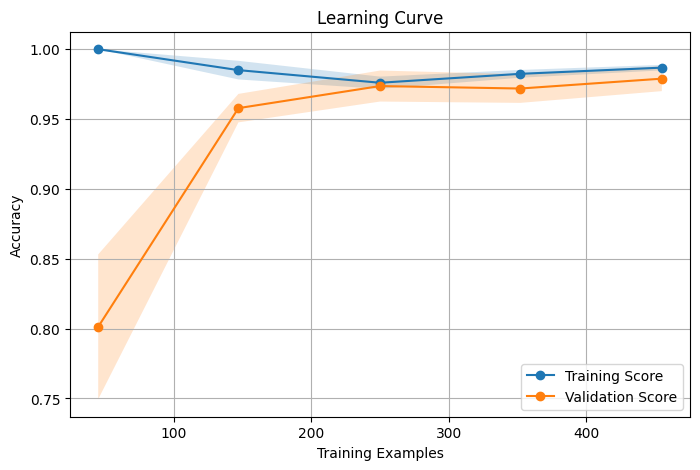

In [109]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_pipeline, X, y, cv=5, scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Score")

plt.fill_between(
    train_sizes,
    train_mean - train_scores.std(axis=1),
    train_mean + train_scores.std(axis=1),
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_scores.std(axis=1),
    val_mean + val_scores.std(axis=1),
    alpha=0.2
)

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [106]:
rf_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',RandomForestClassifier(criterion='log_loss', max_depth=20,random_state=11))
])
rf_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'log_loss'
,max_depth,20
,min_samples_split,2


In [107]:
y_pred_rf = rf_pipeline.predict(X_test)
print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.956140350877193
[[72  0]
 [ 5 37]]


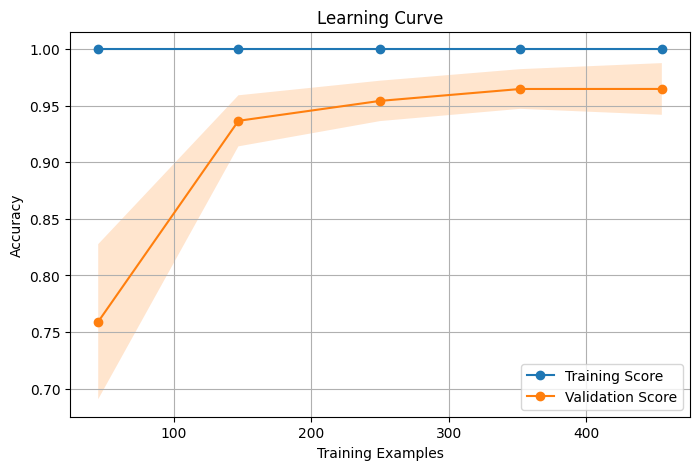

In [110]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_pipeline, X, y, cv=5, scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Score")

plt.fill_between(
    train_sizes,
    train_mean - train_scores.std(axis=1),
    train_mean + train_scores.std(axis=1),
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_scores.std(axis=1),
    val_mean + val_scores.std(axis=1),
    alpha=0.2
)

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [113]:
import joblib
joblib.dump(lr_pipeline , 'breast_cancer.pkl')
print('saved')

saved
